## Homework 5
Damion Huppert

In [46]:
using Pkg
Pkg.add("CSV")
using CSV
Pkg.add("DataFrames")
using DataFrames
Pkg.add("JuMP")
using JuMP
Pkg.add("HiGHS")
using HiGHS
Pkg.add("Plots")
using Plots
Pkg.add("Gurobi")
using Gurobi
Pkg.add("LinearAlgebra")
using LinearAlgebra

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.to

In [ ]:
# Read dataframe
df = CSV.read("nfl_scores-2022.csv", DataFrame)

# Get first 8 weeks
df_8 = filter(:week => x -> x <= 8, df)
println(df_8)
df_9 = filter(:week => x -> x == 9, df)

# Team mapping and home team margin
SCORE_DIFF = Dict{Tuple{String, String}, Int}()

for row in eachrow(df_8)
    if row.tm_location == "H"
        ht = row.tm_name
        at = row.opp_name
        ht_margin = row.tm_score - row.opp_score
    elseif row.tm_location == "A"
        ht = row.opp_name
        at = row.tm_name
        ht_margin = row.opp_score - row.tm_score
    end
    SCORE_DIFF[(ht, at)] = ht_margin
end

TEAMS = unique([ht for (ht,at) in keys(SCORE_DIFF)])
GAMES = keys(SCORE_DIFF)
GAMES


   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


123×7 DataFrame
 Row │ Column1  week   tm_name        opp_name       tm_location  tm_score  opp_score 
     │ Int64    Int64  String15       String15       String1      Int64     Int64     
─────┼────────────────────────────────────────────────────────────────────────────────
   1 │       0      1  Bills          Rams           A                  31         10
   2 │       1      1  Saints         Falcons        A                  27         26
   3 │       2      1  Browns         Panthers       A                  26         24
   4 │       3      1  Bears          49ers          H                  19         10
   5 │       4      1  Steelers       Bengals        A                  23         20
   6 │       5      1  Texans         Colts          H                  20         20
   7 │       6      1  Eagles         Lions          A                  38         35
   8 │       7      1  Football Team  Jaguars        H                  28         22
   9 │       8      1  Dolphins    

KeySet for a Dict{Tuple{String, String}, Int64} with 123 entries. Keys:
  ("Steelers", "Buccaneers")
  ("Saints", "Raiders")
  ("Cowboys", "Football Team")
  ("Browns", "Jets")
  ("Football Team", "Titans")
  ("Jets", "Dolphins")
  ("Dolphins", "Steelers")
  ("Buccaneers", "Packers")
  ("Falcons", "49ers")
  ("Ravens", "Browns")
  ("Vikings", "Lions")
  ("Chargers", "Seahawks")
  ("Seahawks", "Giants")
  ("Falcons", "Browns")
  ("49ers", "Seahawks")
  ("Cardinals", "Chiefs")
  ("Saints", "Seahawks")
  ("Eagles", "Steelers")
  ("Panthers", "Browns")
  ("Titans", "Colts")
  ("Lions", "Dolphins")
  ("Broncos", "Texans")
  ("Football Team", "Packers")
  ("Texans", "Titans")
  ("Raiders", "Cardinals")
  ⋮

##### Question 1-1

Decision Variables:
$$
x_i \quad \text{Perfomance of team i}  
$$
$$
\beta \quad \text{Homefield advantage parameter}  
$$
Constraints 
$$
\sum_{i=1}^{32} x_i = 0 \quad \text{ Rating of all teams combined sums to 0}  
$$
Objective
$$
\min{\sum_{i,j\in G}(x_i - x_j + \beta - \Delta_{ij})^2} \quad \text{ Minimize the squared error for all games, i is the home team and j is the away team}  
$$

##### Question 1-2

In [7]:
# Map team names to indices
team_idx = Dict(t => i for (i, t) in enumerate(TEAMS))

# Build model
model = Model(HiGHS.Optimizer)
@variable(model, x[1:length(TEAMS)])   # team ratings
@variable(model, β)                    # home field advantage

@constraint(model, sum(x) == 0)

@objective(model, Min, sum(
    (x[team_idx[ht]] - x[team_idx[at]] + β - SCORE_DIFF[(ht, at)])^2
    for (ht, at) in GAMES
))

set_silent(model)  # suppress output
optimize!(model)

# Print team ratings
ratings = [(t, value(x[team_idx[t]])) for t in TEAMS]
sort!(ratings, by = x -> -x[2])  # sort descending
println("Team Ratings (highest to lowest):")
for (team, rating) in ratings
    println(rpad(team, 20), round(rating, digits=3))
end

println("\nHome Field Advantage: β = ", round(value(β), digits=3))

Team Ratings (highest to lowest):
Bills               15.777
Eagles              9.666
Chiefs              7.811
Ravens              6.375
Cowboys             5.653
Bengals             4.268
Vikings             3.573
Jets                2.535
49ers               2.511
Patriots            1.683
Dolphins            1.273
Giants              0.705
Buccaneers          0.23
Browns              -0.475
Seahawks            -0.618
Jaguars             -0.995
Falcons             -1.092
Saints              -1.158
Packers             -1.285
Titans              -2.057
Cardinals           -2.593
Bears               -2.742
Raiders             -3.531
Broncos             -3.784
Rams                -3.805
Football Team       -4.042
Panthers            -4.686
Steelers            -4.779
Lions               -5.245
Chargers            -5.292
Colts               -5.333
Texans              -8.547

Home Field Advantage: β = 1.906


##### Question 1-3

Bengals ranking: 4.268  
Chiefs rankning: 7.811  
Homefield advantage: 1.906

$$
4.268 - 7.811 + 1.906 = -1.637
$$
Cheifs win 🥳

##### Question 1-4

In [13]:
# Map team names to indices
team_idx = Dict(t => i for (i, t) in enumerate(TEAMS))

# Build model
model = Model(HiGHS.Optimizer)
@variable(model, x[1:length(TEAMS)])      # team ratings
@variable(model, β)                       # home field advantage
@variable(model, t[1:length(GAMES)] ≥ 0)  # absolute value terms

@constraint(model, sum(x) == 0)
# Add abs-value constraints per game
for (g_idx, (ht, at)) in enumerate(GAMES)
  i = team_idx[ht]
  j = team_idx[at]
  Δ = SCORE_DIFF[(ht, at)]
  @constraint(model, x[i] - x[j] + β - Δ ≤ t[g_idx])
  @constraint(model, -(x[i] - x[j] + β - Δ) ≤ t[g_idx])
end

@objective(model, Min, sum(t))

set_silent(model)  # suppress output
optimize!(model)

# Print team ratings
ratings = [(t, value(x[team_idx[t]])) for t in TEAMS]
sort!(ratings, by = x -> -x[2])  # sort descending
println("Team Ratings (highest to lowest):")
for (team, rating) in ratings
    println(rpad(team, 20), round(rating, digits=3))
end

println("\nHome Field Advantage: β = ", round(value(β), digits=3))

Team Ratings (highest to lowest):
Bills               16.367
Eagles              14.367
Chiefs              10.617
Cowboys             8.867
Ravens              7.867
Bengals             7.617
Cardinals           3.617
Vikings             2.117
Titans              1.617
Raiders             1.367
Chargers            0.867
Giants              0.117
Packers             0.117
Jets                -0.133
Buccaneers          -1.133
Patriots            -1.133
49ers               -1.133
Dolphins            -1.633
Broncos             -1.883
Seahawks            -2.633
Saints              -2.633
Browns              -2.883
Football Team       -3.383
Rams                -4.883
Falcons             -5.383
Colts               -5.633
Steelers            -5.883
Bears               -6.133
Panthers            -6.633
Lions               -7.383
Texans              -7.383
Jaguars             -7.633

Home Field Advantage: β = 1.75


##### Question 1-5

In [17]:
df_9 = filter(:week => x -> x == 9, df)

correct = 0
total = 0

for row in eachrow(df_9)
    if row.tm_location == "H"
        ht = row.tm_name
        at = row.opp_name
        predicted_margin = value(x[team_idx[ht]]) - value(x[team_idx[at]]) + value(β)
        actual_margin = row.tm_score - row.opp_score
    else
        ht = row.opp_name
        at = row.tm_name
        predicted_margin = value(x[team_idx[ht]]) - value(x[team_idx[at]]) + value(β)
        actual_margin = row.opp_score - row.tm_score
    end

    predicted_winner = predicted_margin > 0 ? ht : at
    actual_winner = actual_margin > 0 ? ht : at
    is_correct = predicted_winner == actual_winner

    correct += is_correct ? 1 : 0
    total += 1

    println(ht, " vs ", at,
        " | Predicted Margin: ", round(predicted_margin, digits=2),
        " | Actual Margin: ", round(actual_margin, digits=2),
        " | Predicted Winner: ", predicted_winner,
        " | Actual Winner: ", actual_winner,
        " | Correct: ", is_correct)
end

println("\nCorrect Week 9 Predictions: ", correct, "/", total)


Texans vs Eagles | Predicted Margin: -20.0 | Actual Margin: -12.0 | Predicted Winner: Eagles | Actual Winner: Eagles | Correct: true
Jets vs Bills | Predicted Margin: -14.75 | Actual Margin: 3.0 | Predicted Winner: Bills | Actual Winner: Jets | Correct: false
Lions vs Packers | Predicted Margin: -5.75 | Actual Margin: 6.0 | Predicted Winner: Packers | Actual Winner: Lions | Correct: false
Football Team vs Vikings | Predicted Margin: -3.75 | Actual Margin: -3.0 | Predicted Winner: Vikings | Actual Winner: Vikings | Correct: true
Falcons vs Chargers | Predicted Margin: -4.5 | Actual Margin: -3.0 | Predicted Winner: Chargers | Actual Winner: Chargers | Correct: true
Bengals vs Panthers | Predicted Margin: 16.0 | Actual Margin: 21.0 | Predicted Winner: Bengals | Actual Winner: Bengals | Correct: true
Bears vs Dolphins | Predicted Margin: -2.75 | Actual Margin: -3.0 | Predicted Winner: Dolphins | Actual Winner: Dolphins | Correct: true
Patriots vs Colts | Predicted Margin: 6.25 | Actual Mar

##### Question 2-1

In [19]:
using JuMP, HiGHS, Printf

k = 60              # number of seconds
dt = 1 / 3600  # seconds to hours

m = Model(HiGHS.Optimizer) 
set_silent(m)
# ANAKIN
@variable(m, xa[1:2,1:k])  # position at each time (miles)
@variable(m, va[1:2,1:k])  # velocity at each time (mph)
@variable(m, ua[1:2,1:k])  # thruster input at each time
# PALPATINE
@variable(m, xp[1:2,1:k])  # position at each time (miles)
@variable(m, vp[1:2,1:k])  # velocity at each time (mph)
@variable(m, up[1:2,1:k])  # thruster input at each time

# satisfy the dynamics (with zero initial velocity)
# Note the use of '.' form of constraints, to make the constraints hold for each component of the vector 

@constraint(m, va[:,1] .== [0.0;20.0]) # initial speed of ANAKIN (20 mph north)
@constraint(m, xa[:,1] .== [0;0.0]) # initial position of ANAKIN ((0,0) he is the reference point)
@constraint(m, vp[:,1] .== [30.0;0.0]) # initial speed of PALPATINE (30 mph east)
@constraint(m, xp[:,1] .== [0.5;0.0]) # initial position of PALPATINE ((1/2,0) he is a half mile east of ANAKIN)

# Dynamics constraints
for t in 1:k-1
  @constraint(m, xa[:,t+1] .== xa[:,t] + dt * va[:,t])
  @constraint(m, va[:,t+1] .== va[:,t] + ua[:,t])
  
  @constraint(m, xp[:,t+1] .== xp[:,t] + dt * vp[:,t])
  @constraint(m, vp[:,t+1] .== vp[:,t] + up[:,t])
end

@constraint(m, xa[:,k] .== xp[:,k])

@objective(m, Min, sum(ua.^2) + sum(up.^2))
optimize!(m)

# Results
final_pos = value.(xa[:,k])
total_energy = objective_value(m)
@printf("Final position: (%.4f miles, %.4f miles)\n", final_pos...)
@printf("Minimum total energy: %.4f\n", total_energy)


Final position: (0.4958 miles, 0.1639 miles)
Minimum total energy: 105.9307


##### Question 2-2

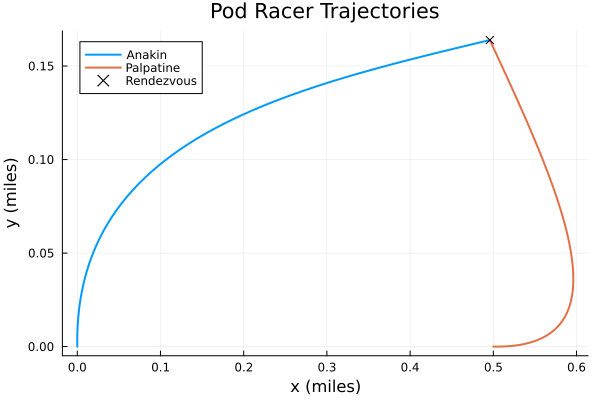

In [20]:
xa_vals = value.(xa)
xp_vals = value.(xp)

plot(xa_vals[1,:], xa_vals[2,:], label="Anakin", lw=2)
plot!(xp_vals[1,:], xp_vals[2,:], label="Palpatine", lw=2)
scatter!([final_pos[1]], [final_pos[2]], label="Rendezvous", color=:black, marker=:x)
xlabel!("x (miles)")
ylabel!("y (miles)")
title!("Pod Racer Trajectories")


##### Question 2-3

In [21]:
using JuMP, HiGHS, Printf

k = 60              # number of seconds
dt = 1 / 3600  # seconds to hours

m = Model(HiGHS.Optimizer) 
set_silent(m)
# ANAKIN
@variable(m, xa[1:2,1:k])  # position at each time (miles)
@variable(m, va[1:2,1:k])  # velocity at each time (mph)
@variable(m, ua[1:2,1:k])  # thruster input at each time
# PALPATINE
@variable(m, xp[1:2,1:k])  # position at each time (miles)
@variable(m, vp[1:2,1:k])  # velocity at each time (mph)
@variable(m, up[1:2,1:k])  # thruster input at each time

# satisfy the dynamics (with zero initial velocity)
# Note the use of '.' form of constraints, to make the constraints hold for each component of the vector 

@constraint(m, va[:,1] .== [0.0;20.0]) # initial speed of ANAKIN (20 mph north)
@constraint(m, va[:,60] .== [0.0;0.0]) # final speed of ANAKIN (0 mph)
@constraint(m, xa[:,1] .== [0;0.0]) # initial position of ANAKIN ((0,0) he is the reference point)
@constraint(m, vp[:,1] .== [30.0;0.0]) # initial speed of PALPATINE (30 mph east)
@constraint(m, vp[:,60] .== [0.0;0.0]) # final speed of PALPATINE (0 mph)
@constraint(m, xp[:,1] .== [0.5;0.0]) # initial position of PALPATINE ((1/2,0) he is a half mile east of ANAKIN)

# Dynamics constraints
for t in 1:k-1
  @constraint(m, xa[:,t+1] .== xa[:,t] + dt * va[:,t])
  @constraint(m, va[:,t+1] .== va[:,t] + ua[:,t])
  
  @constraint(m, xp[:,t+1] .== xp[:,t] + dt * vp[:,t])
  @constraint(m, vp[:,t+1] .== vp[:,t] + up[:,t])
end

@constraint(m, xa[:,k] .== xp[:,k])

@objective(m, Min, sum(ua.^2) + sum(up.^2))
optimize!(m)

# Results
final_pos = value.(xa[:,k])
total_energy = objective_value(m)
@printf("Final position: (%.4f miles, %.4f miles)\n", final_pos...)
@printf("Minimum total energy: %.4f\n", total_energy)


Final position: (0.3750 miles, 0.0833 miles)
Minimum total energy: 245.5874


##### Question 2-4

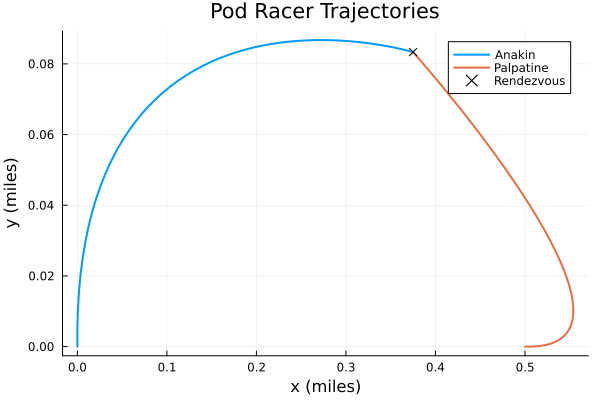

In [22]:
xa_vals = value.(xa)
xp_vals = value.(xp)

plot(xa_vals[1,:], xa_vals[2,:], label="Anakin", lw=2)
plot!(xp_vals[1,:], xp_vals[2,:], label="Palpatine", lw=2)
scatter!([final_pos[1]], [final_pos[2]], label="Rendezvous", color=:black, marker=:x)
xlabel!("x (miles)")
ylabel!("y (miles)")
title!("Pod Racer Trajectories")


##### Question 3-1

Decision Variables  
$$
h_i \quad \text{ CURRENT percent holding of asset i }
$$
$$
x_i \quad \text{ NEW portfolio holding of asset i }
$$
$$
\text{buy}_i \quad \text{Amount of asset i to buy}
$$
$$
\text{sell}_i \quad \text{Amount of asset i to sell}
$$

Objective
$$
\min{\sum_{i \in A}(\text{sell}_i + \text{buy}_i)} \quad \text{ Minimize the total number of dollars that must
be bought or sold }
$$

Subject To
$$
x_i = h_i + \text{buy}_i - \text{sell}_i
$$
$$
\sqrt{(x-b)^TQ(x-b)} \leq 0.10
$$
$$
\sum_{i \in A}x_i = 1
$$

In [25]:
df = CSV.read("folio_mean.csv", DataFrame, header=false, delim=',')
df2 = CSV.read("folio_cov.csv",DataFrame,header=false,delim=',')
df3 = CSV.read("folio_holding_benchmark.csv", DataFrame, header=false, delim=',')

(n,mmm) = size(df)
mu = -100/7*365*Vector(df[1:n,1])

Q = 0.5* (100/7*365)^2 * Matrix(df2)
h = Vector(df3[1:n,1])
b = Vector(df3[1:n,2])
benchmark_return = mu'b
holdings_return = mu'*h
active_risk = sqrt((h-b)'Q*(h-b))
println("Benchmark expected return: ", benchmark_return)
println("Holdings expected return: ", holdings_return)
println("Active Risk: ", active_risk)

Benchmark expected return: 9.48798378650461
Holdings expected return: 5.67073489826738
Active Risk: 32.90926641232401


In [43]:
model = Model(Gurobi.Optimizer)

@variable(model, x[1:n] >= 0)
@variable(model, buy[1:n] >= 0)
@variable(model, sell[1:n] >= 0)

@objective(model, Min, sum(buy + sell))

@constraint(model, x .== h .+ buy .- sell)
@constraint(model, sum(x) == 1)
@constraint(model, (x-b)'*Q*(x-b) <= 0.01)

set_silent(model)
optimize!(model)

if termination_status(model) == MOI.OPTIMAL
  obj_value = objective_value(model)
  x_opt = value.(x)
  buy_opt = value.(buy)
  sell_opt = value.(sell)

  println("Total number of dollars transacted: ", obj_value*1000000000)
  println("Expected return: ", value(mu'x))
  println("Active risk: ", value(sqrt((x-b)'Q*(x-b))))
else
  println("Optimization did not succeed. Status: ", termination_status(model))
end

Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Total number of dollars transacted: 1.8965096546548574e9
Expected return: 9.484021719438463
Active risk: 0.09993267508857184


##### Question 3-3

Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
Set parameter Username
Set parameter LicenseID to value 2649580
Academic lic

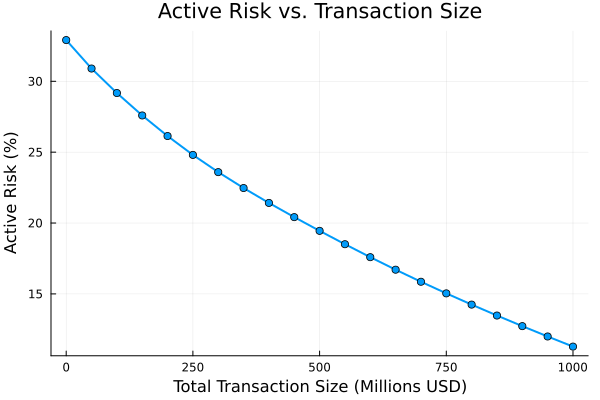

In [47]:
transaction_limits = 0:50e6:1e9
active_risks = Float64[]
expected_returns = Float64[]

# Loop over different transaction limits
for T in transaction_limits
    model = Model(Gurobi.Optimizer)
    set_silent(model)

    @variable(model, x[1:n] >= 0)
    @variable(model, buy[1:n] >= 0)
    @variable(model, sell[1:n] >= 0)

    @constraint(model, x .== h .+ buy .- sell)
    @constraint(model, sum(x) == 1)
    @constraint(model, sum(buy) + sum(sell) <= T / 1e9)  # Divide by 1B to match fraction units

    # Minimize active risk
    @objective(model, Min, (x - b)' * Q * (x - b))

    optimize!(model)

    if termination_status(model) == MOI.OPTIMAL
        push!(active_risks, sqrt(objective_value(model)))
        push!(expected_returns, dot(mu, value.(x)))
    else
        push!(active_risks, NaN)
        push!(expected_returns, NaN)
        println("Solver failed at transaction limit \$", T)
    end
end

# Plot active risk vs transaction size
plot(transaction_limits ./ 1e6, active_risks,
    xlabel="Total Transaction Size (Millions USD)",
    ylabel="Active Risk (%)",
    title="Active Risk vs. Transaction Size",
    legend=false,
    lw=2,
    marker=:circle)

##### Question 4-1

Decision Variables:
$$
x_i \quad \text{1 if the factory opens 0 otherwise}
$$
$$
b_{ib} \quad \text{cupcakes shipped from plant i to bakery b}
$$

Parameters:  
- $ s_i $: Maximum supply capacity of plant $ i $
- $ c_i $: Fixed cost of opening plant $ i $
- $ t_{ib} $: Transportation cost per cupcake from plant $ i $ to bakery $ b $
- $ d_b $: Monthly demand of bakery $ b $

Objective:  
$$
\min \sum_{i \in P} c_i x_i + \sum_{i \in P} \sum_{b \in B} t_{ib} \cdot b_{ib}
$$

Subject to:
$$
\sum_{i \in P} b_{ib} = d_b \quad \forall b \in B
$$
$$
\sum_{b \in B} b_{ib} \leq s_i \cdot x_i \quad \forall i \in P
$$
$$
b_{ib} \geq 0 \quad \forall i \in P, b \in B
$$
$$
x_i \in \{0, 1\} \quad \forall i \in P
$$

##### Question 4-2

In [48]:

plant_supply = [1600, 1500, 1200]
bakery_demand = [1600, 900, 1000]
fixed_cost = [10000, 11000, 9000]
cost = [
    15 10 12;
    20 18 21;
    17 15 11
]

num_plants = 3
num_bakeries = 3

model = Model(Gurobi.Optimizer)
set_silent(model)

@variable(model, x[1:num_plants, 1:num_bakeries] >= 0)
@variable(model, y[1:num_plants], Bin)

@objective(model, Min, sum(cost[i,j]*x[i,j] for i in 1:3, j in 1:3) + sum(fixed_cost[i]*y[i] for i in 1:3))

for j in 1:num_bakeries
    @constraint(model, sum(x[i,j] for i in 1:num_plants) == bakery_demand[j])
end

for i in 1:num_plants
    @constraint(model, sum(x[i,j] for j in 1:num_bakeries) <= plant_supply[i] * y[i])
end

optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("✅ Minimum Monthly Cost: \$", objective_value(model))
    println("📦 Open Plants:")
    for i in 1:num_plants
        println("  Plant $i: ", value(y[i]) > 0.5 ? "Open" : "Closed")
    end
    println("\n🚚 Shipping Plan:")
    for i in 1:num_plants
        for j in 1:num_bakeries
            shipped = value(x[i,j])
            if shipped > 1e-6
                println("  Ship ", round(shipped), " cupcakes from Plant $i to Bakery $j")
            end
        end
    end
else
    println("Optimization failed with status: ", termination_status(model))
end


Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
✅ Minimum Monthly Cost: $77900.0
📦 Open Plants:
  Plant 1: Open
  Plant 2: Open
  Plant 3: Open

🚚 Shipping Plan:
  Ship 700.0 cupcakes from Plant 1 to Bakery 1
  Ship 900.0 cupcakes from Plant 1 to Bakery 2
  Ship 700.0 cupcakes from Plant 2 to Bakery 1
  Ship 200.0 cupcakes from Plant 3 to Bakery 1
  Ship 1000.0 cupcakes from Plant 3 to Bakery 3


##### Question 5-1

Sets:
- $ B = \{1, 2, 3\} $: Boilers
- $ T = \{1, 2, 3\} $: Turbines

Decision Variables:
$$
x_i \quad \text{tons of steam produced by boiler $i$}
$$
$$
b_i \in \{0, 1\} \quad \text{1 if boiler i is used, 0 otherwise}
$$
$$
s_j \quad \text{tons of steam processed by turbine $j$ }
$$
$$
z_j \in \{0, 1\} \quad \text{ 1 if turbine $j$ is used, 0 otherwise}
$$

Parameters:  
$$
c_i \quad \text{cost per ton produced from boiler i}
$$
$$
q_j \quad \text{cost per ton proccessed from turbine j}
$$
$$
p_j \quad \text{power produced per ton of steam}
$$

Objective:  
$$
\min \sum_{i=1}^{3} c_i x_i + \sum_{j=1}^{3} q_j s_j
$$

Subject to:
$$
\text{min}_i b_i \leq x_i \leq \text{max}_i b_i \quad \forall i \in B
$$
$$
\text{min}_j z_j \leq s_j \leq \text{max}_j z_j \quad \forall j \in T
$$
$$
\sum_{i=1}^{3} x_i = \sum_{j=1}^{3} s_j
$$
$$
\sum_{j=1}^{3} p_j s_j \geq 8000
$$
$$
b_i, z_j \in \{0, 1\}
$$


##### Question 5-2

In [ ]:
boiler_min = [400, 200, 300]
boiler_max = [1000, 900, 800]
boiler_cost = [10, 8, 7]
turbine_min = [300, 500, 600]
turbine_max = [600, 800, 900]
turbine_power = [4, 5, 6]
turbine_cost = [2, 3, 4]
required_power = 8000

model = Model(Gurobi.Optimizer)
set_silent(model)

@variable(model, 0 <= x[1:3])
@variable(model, b[1:3], Bin)
@variable(model, 0 <= s[1:3])
@variable(model, z[1:3], Bin)

@objective(model, Min, sum(boiler_cost[i] * x[i] for i in 1:3) + sum(turbine_cost[j] * s[j] for j in 1:3))

for i in 1:3
    @constraint(model, boiler_min[i] * b[i] <= x[i])
    @constraint(model, x[i] <= boiler_max[i] * b[i])
end

for j in 1:3
    @constraint(model, turbine_min[j] * z[j] <= s[j])
    @constraint(model, s[j] <= turbine_max[j] * z[j])
end

@constraint(model, sum(x) == sum(s))
@constraint(model, sum(turbine_power[j] * s[j] for j in 1:3) >= required_power)

optimize!(model)

if termination_status(model) == MOI.OPTIMAL
    println("✅ Minimum Total Cost: \$", objective_value(model))
    for i in 1:3
        println("Boiler B$i: ", value(y[i]) > 0.5 ? "On, " : "Off, ",
                "Steam Produced = ", round(value(x[i]), digits=2), " tons")
    end
    for j in 1:3
        println("Turbine T$j: ", value(z[j]) > 0.5 ? "On, " : "Off, ",
                "Steam Processed = ", round(value(s[j]), digits=2), " tons, ",
                "Power = ", round(turbine_power[j] * value(s[j]), digits=2), " kWh")
    end
else
    println("❌ Optimization failed: ", termination_status(model))
end


Set parameter Username
Set parameter LicenseID to value 2649580
Academic license - for non-commercial use only - expires 2026-04-09
✅ Minimum Total Cost: $15720.0
Boiler B1: On, Steam Produced = 0.0 tons
Boiler B2: On, Steam Produced = 620.0 tons
Boiler B3: On, Steam Produced = 800.0 tons
Turbine T1: Off, Steam Processed = 0.0 tons, Power = 0.0 kWh
Turbine T2: On, Steam Processed = 520.0 tons, Power = 2600.0 kWh
Turbine T3: On, Steam Processed = 900.0 tons, Power = 5400.0 kWh
